In [ ]:
%pip install lightning

In [ ]:
from google.colab import drive
# Mount the Google Drive at /content/drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%mkdir -p  /content/data
%cp -r /content/drive/MyDrive/COVID-19_Radiography_Dataset.zip /content/data/
%cd /content/data
!unzip -q COVID-19_Radiography_Dataset.zip

/content/data


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

class CustomConvNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=False):
        super(CustomConvNet, self).__init__()

        # Load a pretrained ResNet model (you can choose ResNet18, ResNet34, ResNet50, ResNet101, etc.)
        self.resnet = models.resnet50(pretrained=pretrained)  # You can change this to other ResNet variants
               # Modify the final fully connected layer to match the number of classes in your task
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, num_classes)  # num_classes is the output dimension (10 by default)
        self.softmax = nn.Sigmoid()

    def forward(self, x):
        resnet_features = self.resnet(x)

        classes = self.softmax(resnet_features)
        return classes

In [ ]:
import torch
import torch.nn as nn
import lightning as L
from torchmetrics.classification import BinaryAccuracy, BinarySpecificity, BinaryROC
from torch.optim.lr_scheduler import ReduceLROnPlateau

import io
import PIL.Image
import numpy as np


class LitClassifier(L.LightningModule):
    def __init__(self, classifier:nn.Module):
        super().__init__()
        self.classifier = classifier
        self.loss_fn = nn.BCELoss()
        self.train_acc = BinaryAccuracy()
        self.train_spec = BinarySpecificity()
        self.train_roc = BinaryROC(thresholds=20)
    def test_step(self, batch, batch_idx):
        # training_step defines the train loop.
        data,_,labels = batch
        labels =torch.unsqueeze(labels.float(),1)
        output = self.classifier(data)

        print(f'outputs:{output}')
        print(f'labels:{labels}')


        self.train_roc.update(output,labels.long())

    def validation_step(self, batch, batch_idx):
        data,_,labels = batch
        labels =torch.unsqueeze(labels.float(),1)
        output = self.classifier(data)
        loss = self.loss_fn(output,labels)
        self.log('valid_loss',loss, on_step=False, on_epoch=True)
        acc = self.train_acc(output,labels)
        self.log('valid_acc',acc, on_step=False, on_epoch=True)
        spec = self.train_spec(output,labels)

        return loss


    def training_step(self, batch, batch_idx):
        # training_step defines the train loop.
        data,_,labels = batch
        labels =torch.unsqueeze(labels.float(),1)
        output = self.classifier(data)
        loss = self.loss_fn(output,labels)
        self.log('train_loss',loss, on_step=False, on_epoch=True)
        acc = self.train_acc(output,labels)
        self.log('train_acc',acc, on_step=False, on_epoch=True)
        spec = self.train_spec(output,labels)
        self.log('train_spec',spec, on_step=False, on_epoch=True)
        self.train_roc.update(output,labels.long())
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.0001)

      # Define the learning rate scheduler (ReduceLROnPlateau)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=True)

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'valid_loss',  # Metric to monitor for reduction
                'interval': 'epoch',  # When to update the scheduler (here every epoch)
                'frequency': 1  # Frequency of applying the scheduler
            }
        }



In [ ]:
import os
import torch
import pandas as pd
from skimage import io,color
from torch.utils.data import Dataset
from torchvision import transforms
#this is dataset for lungs
class LungDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform):
        self.root_dir = root_dir
        self.dataset_csv = pd.read_csv(csv_file)
        self.transform = transform
        self.string_to_label = {
            'COVID': 1,
            'Normal': 0,
            'Viral Pneumonia': 1 # map these both to abnormal
        }

    def get_sklearn_representation(self):
      data = []
      labels = []
      for datum, mask, label in self:
        data.append(data)
        labels.append(label)
      return data, labels


    def __len__(self):
        return len(self.dataset_csv)


    def __getitem__(self, index):
        if torch.is_tensor(index):
            index = index.tolist()
        category = self.dataset_csv.iloc[index, 1]
        # pull index from csv file
        image_name = os.path.join(self.root_dir, category,"images/", self.dataset_csv.iloc[index, 0])
        mask_name = os.path.join(self.root_dir, category,"masks/", self.dataset_csv.iloc[index, 0])

        ## get image and mask and category integer
        return_image = io.imread(image_name)
        if len(return_image.shape) == 3 and return_image.shape[2] == 3:
            return_image = color.rgb2gray(return_image)
        return_image = torch.tensor(return_image)
        return_image = self.transform(return_image)

        return_lung_mask = torch.tensor(color.rgb2gray(io.imread(mask_name)))
        return_image =torch.where( return_lung_mask == 1, return_image,0)
        return_image = (torch.tensor(color.gray2rgb(return_image)).permute(2,0,1)/255.0).float();
        return_category = self.string_to_label[category]        ##map category to labels using dictionary



        return return_image,return_lung_mask,  return_category


In [ ]:

from torchvision import transforms
from torch.utils.data import DataLoader
import logging
import lightning as L
from pytorch_lightning.loggers import TensorBoardLogger
import logging
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from typing import List

from lightning.pytorch.callbacks import ModelCheckpoint
import torch.nn as nn
import torch
import numpy as np
#logging setup crap
logging.basicConfig(level=logging.INFO)
formatter = logging.Formatter(
    '[%(levelname)s:  %(asctime)s] - %(name)s  - %(message)s')
ch = logging.StreamHandler()
ch.setFormatter(formatter)
logger = logging.getLogger(__name__)
logger.addHandler(ch)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


checkpoint_callback = ModelCheckpoint( monitor='valid_loss')
tf = transforms.Compose([transforms.CenterCrop(256), ]);

logger.info("Loading dataset..")
dataset = LungDataset('/content/drive/MyDrive/train_file.csv','/content/data/COVID-19_Radiography_Dataset',tf)
from torch.utils.data import random_split
# Set the proportion for validation data (e.g., 80% for training, 20% for validation)
train_size = int(0.9 * len(dataset))  # 80% for training
val_size = len(dataset) - train_size  # 20% for validation

# Split the dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


logger.info("Creatin Model ...")
conv_net = CustomConvNet(num_classes=1)

logger.info("Initializing Trainer ...")
classifier  = LitClassifier(conv_net)

# Initialize TensorBoard logger
tb_logger = TensorBoardLogger("logs/", name="my_model")

# Set up trainer with the logger
trainer = L.Trainer(logger=tb_logger, max_epochs=50, callbacks=[checkpoint_callback])
trainer.fit(model=classifier,train_dataloaders=train_loader, val_dataloaders=val_loader)





/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name       | Type              | Params | Mode 
--------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Streaming output truncated to the last 5000 lines.
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
torch.Size([1, 2048])
tor

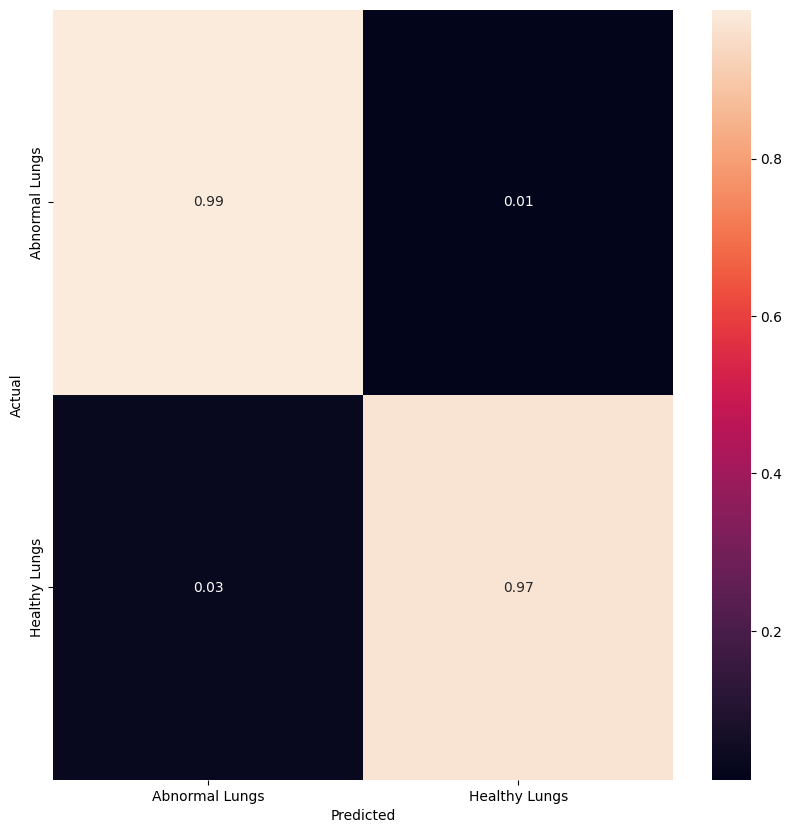

In [ ]:
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import click
from torchvision import transforms
import logging
import lightning as L
import matplotlib.pyplot as plt
from typing import List
import pickle
from torchvision import transforms
from torch.utils.data import DataLoader

import seaborn as sns
from sklearn import svm
import torch.nn as nn
import torch
import numpy as np

logging.basicConfig(level=logging.INFO)
formatter = logging.Formatter(
    '[%(levelname)s:  %(asctime)s] - %(name)s  - %(message)s')
ch = logging.StreamHandler()
ch.setFormatter(formatter)
logger = logging.getLogger(__name__)
logger.addHandler(ch)



def extract_embeddings(model, data_loader):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    embeddings = []
    images = []
    labels = []
    with torch.no_grad():
        for data in data_loader:
            img,_, label = data
            img = img.to(device)
            embedding = torch.unsqueeze(torch.squeeze(model(img)),0)
            embeddings.append(embedding.cpu().numpy())

            print(embedding.shape)
            images.append(torch.unsqueeze(img.flatten(),0).cpu().numpy())
            labels.append(label.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)
    images = np.concatenate(images, axis=0)
    labels = np.concatenate(labels, axis=0)
    return embeddings, labels,images




tf = transforms.Compose([transforms.CenterCrop(256), ]);

logger.info("Loading dataset..")
dataset = LungDataset('/content/drive/MyDrive/train_file.csv','/content/data/COVID-19_Radiography_Dataset',tf)
test_loader = DataLoader(dataset,batch_size=1);

logger.info("Creatin Model ...")
conv_net = CustomConvNet(num_classes=1)

model = LitClassifier.load_from_checkpoint('/content/drive/MyDrive/version_4/checkpoints/epoch=18-step=1634.ckpt',classifier=conv_net)
feature_extractor = nn.Sequential(*list(model.classifier.resnet.children())[:-1])

#have to flip lables because I messed up with OG dataset

embeddings, labels, images = extract_embeddings(feature_extractor, test_loader)
clf = svm.SVC(kernel='linear', C=0.01a,  probability=True )
embeddings = np.squeeze(embeddings)
clf.fit(np.squeeze(embeddings), labels)

predictions = clf.predict(np.squeeze(embeddings))
cm = confusion_matrix(labels, predictions, labels=clf.classes_)

cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=['Abnormal Lungs', 'Healthy Lungs'], yticklabels=['Abnormal Lungs', 'Healthy Lungs'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)

In [ ]:
# Save the model to a file using pickle
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(clf, f)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


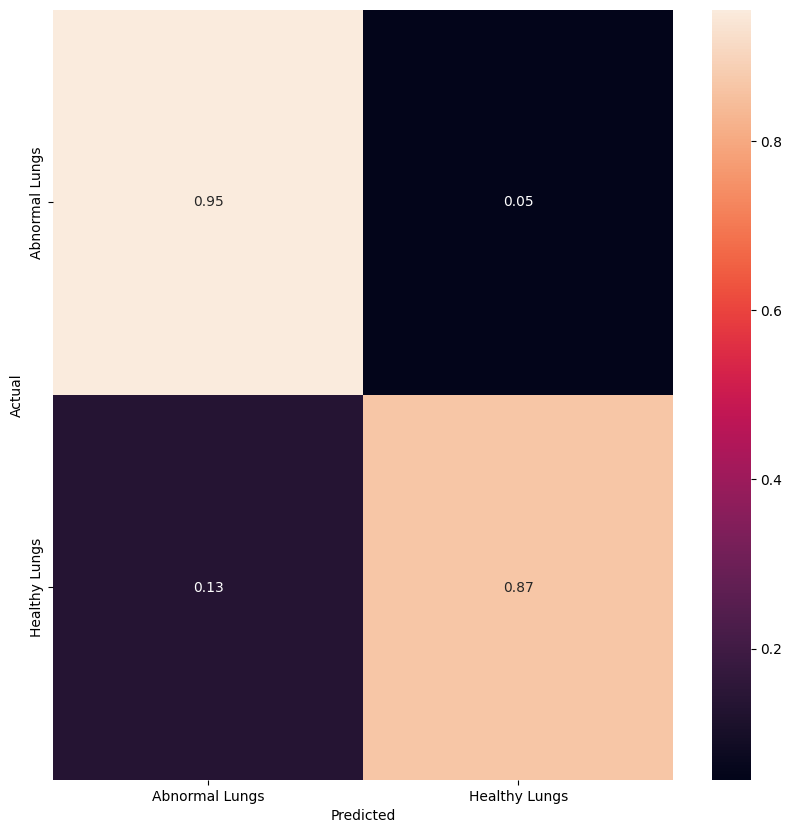

In [ ]:
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import click
from torchvision import transforms
import logging
import lightning as L
import matplotlib.pyplot as plt
from typing import List
import pickle


import seaborn as sns
from sklearn import svm
import torch.nn as nn
import torch
import numpy as np



def extract_embeddings(model, data_loader):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    embeddings = []
    images = []
    labels = []
    with torch.no_grad():
        for data in data_loader:
            img,_, label = data
            img = img.to(device)
            embedding = torch.unsqueeze(torch.squeeze(model(img)),0)
            embeddings.append(embedding.cpu().numpy())
            images.append(torch.unsqueeze(img.flatten(),0).cpu().numpy())
            labels.append(label.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)
    images = np.concatenate(images, axis=0)
    labels = np.concatenate(labels, axis=0)
    return embeddings, labels,images




tf = transforms.Compose([transforms.CenterCrop(256), ]);

logger.info("Loading dataset..")
dataset = LungDataset('/content/drive/MyDrive/test_file.csv','/content/data/COVID-19_Radiography_Dataset',tf)
test_loader = DataLoader(dataset,batch_size=1);

logger.info("Creatin Model ...")
conv_net = CustomConvNet(num_classes=1)

model = LitClassifier.load_from_checkpoint('/content/drive/MyDrive/version_4/checkpoints/epoch=18-step=1634.ckpt',classifier=conv_net)
feature_extractor = nn.Sequential(*list(model.classifier.resnet.children())[:-1])
embeddings, labels, images = extract_embeddings(feature_extractor, test_loader)
embeddings = np.squeeze(embeddings)
predictions = clf.predict(np.squeeze(embeddings))
cm = confusion_matrix(labels, predictions, labels=clf.classes_)

cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=['Abnormal Lungs', 'Healthy Lungs'], yticklabels=['Abnormal Lungs', 'Healthy Lungs'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)

(3031, 2)


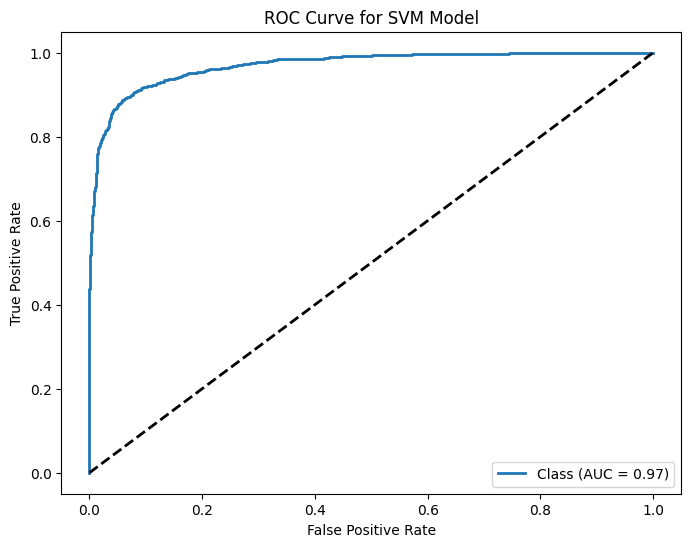

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc


y_score = clf.predict_proba(embeddings)

# Initialize the plot
plt.figure(figsize=(8, 6))

print(y_score.shape)


# Compute ROC curve and AUC for each class
fpr, tpr, _ = roc_curve(labels, y_score[:,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, lw=2, label=f'Class (AUC = {roc_auc:.2f})')

# Plotting the diagonal line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM Model')
plt.legend(loc='lower right')

# Show the plot
plt.show()

In [ ]:
y_score[0,0]

np.float64(1.4891382337497005e-07)